# Hybrid EHR Condition Prediction Model
## End-to-End Pipeline: EDA → Feature Engineering → Hybrid MLP + BioClinical Architecture

**Dataset:** Synthetic Medical Dataset (~1,462 patients, 10 relational tables)  
**Task:** Multilabel prediction of top clinical conditions per patient  
**Architecture:** Tabular MLP branch + Frozen BioClinical text branch → Fusion → Sigmoid classifier

---
### Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Schema Overview](#2-data-loading)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Target Label Definition (Multilabel)](#4-target-labels)
5. [Feature Engineering Pipeline](#5-feature-engineering)
   - 5.1 Demographics
   - 5.2 Temporal Lab/Observation Pivots (Rolling Windows)
   - 5.3 Clinical History (Multi-hot Conditions & Allergies)
   - 5.4 Medications (Therapeutic Classes)
   - 5.5 Utilisation (Procedures, Encounters, Immunisations)
   - 5.6 Master Feature Matrix Assembly
6. [Feature Importance & Selection (LightGBM)](#6-feature-importance)
7. [Clinical Text Synthesis (LLM Prompt Template)](#7-text-synthesis)
8. [Dataset Splits (Patient-Level K-Fold)](#8-dataset-splits)
9. [Tabular Branch: MLP with BatchNorm & Dropout](#9-mlp-branch)
10. [Text Branch: Frozen BioClinical Encoder + Projection Head](#10-text-branch)
11. [Fusion & Classification Head](#11-fusion)
12. [Training Loop with Class Weighting & Label Smoothing](#12-training)
13. [Evaluation: AUC-ROC, F1-macro, Per-label Metrics](#13-evaluation)
14. [Threshold Tuning per Label](#14-threshold-tuning)
15. [Optional: Unfreeze Top BioClinical Layers (Fine-tuning Pass)](#15-fine-tuning)


## 1. Environment Setup <a id='1-environment-setup'></a>

In [1]:
!pip install --upgrade torch --index-url https://download.pytorch.org/whl/cu126

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 118.8 MB/s eta 0:00:22
    --------------------------------------- 0.0/2.6 GB 118.8 MB/s eta 0:00:22
   - -------------------------------------- 0.1/2.6 GB 118.8 MB/s eta 0:00:22
   - -------------------------------------- 0.1/2.6 GB 118.5 MB/s eta 0:00:22
   - -------------------------------------- 0.1/2.6 GB 118.3 MB/s eta 0:00:22
   -- ------------------------------------- 0.1/2.6 GB 118.4 MB/s eta 0:00:21
   -- ------------------------------------- 0.2/2.6 GB 118.5 MB/s eta 0:00:21
   -- ------------------------------------- 0.2/2.6 GB 118.3 MB/s eta 0:00:21
   --- ------------------------------------ 0.2/2.6 GB 118.3 MB/s eta 0:00:21
   --- ------------------------------------ 0.2/2.6 GB 118.2 MB/s eta 0:00:21
   ---- ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import torch
torch.cuda.is_available(), torch.__version__, torch.cuda._is_compiled()

(True, '2.12.0+cu126', True)

In [4]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn lightgbm transformers flash-attn
!pip install imbalanced-learn tqdm
!pip install torch --index-url https://download.pytorch.org/whl/cu130

Defaulting to user installation because normal site-packages is not writeable
  Using cached flash_attn-2.8.3.tar.gz (8.4 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      
      
      torch.__version__  = 2.12.0+cu126
      
      
      C:\Users\vo25aag\AppData\Local\Temp\pip-install-1y1kalm0\flash-attn_8fbdf9741cf543fbb1d5475512d18325\setup.py:106: UserWarning: flash_attn was requested, but nvcc was not found.  Are you sure your environment has nvcc available?  If you're installing within a container from https://hub.docker.com/r/pytorch/pytorch, only images whose names contain 'devel' will provide nvcc.
        warnings.warn(
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 35, in <module>
        File "C:\Users\vo25aag\AppData\Local\Temp\pip-install-1y1kalm0\flash-attn_8fbdf9741cf543fbb1d5475512d18325\setup.py", line 227, in <module>
          CUDAExtension(
        File "C:\Users\vo25aag\AppData\Roaming\Python\Python312\sit

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu130


In [5]:
!pip install groq

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# PyTorch & Transformers
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.feature_selection import VarianceThreshold

# LightGBM for feature importance
import lightgbm as lgb

# Transformers (for BioClinical / BiomedNLP and LLM Call)
from transformers import AutoTokenizer, AutoModel
from dotenv import load_dotenv

load_dotenv()

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# configuration 
DATA_DIR = Path('data')
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')


Device: cuda
PyTorch version: 2.12.0+cu126


## 2. Data Loading & Schema Overview <a id='2-data-loading'></a>

We load all 10 CSV tables. Every table links back to `PATIENT` (or `patient` in the patients table),
which is our primary join key throughout the pipeline.


In [2]:
def load_csv(name, dir_=DATA_DIR):
    """Load a CSV and standardise column names to UPPER_CASE for consistency."""
    df = pd.read_csv(dir_ / f'{name}.csv')
    # patients table uses lower-case columns; standardise
    df.columns = df.columns.str.strip().str.upper()
    return df

patients      = load_csv('patients')
conditions    = load_csv('conditions')
observations  = load_csv('observations')
medications   = load_csv('medications')
procedures    = load_csv('procedures')
immunizations = load_csv('immunizations')
careplans     = load_csv('careplans')
allergies     = load_csv('allergies')
encounters    = load_csv('encounters')
prevalences   = load_csv('all_prevalences')

# Rename patient-id column in patients table to match other tables 
patients.rename(columns={'PATIENT': 'PATIENT'}, inplace=True)  # already PATIENT after upper()

tables = {
    'patients': patients, 'conditions': conditions,
    'observations': observations, 'medications': medications,
    'procedures': procedures, 'immunizations': immunizations,
    'careplans': careplans, 'allergies': allergies,
    'encounters': encounters, 'prevalences': prevalences,
}
for name, df in tables.items():
    print(f'{name:>15s}  →  {df.shape[0]:>6,} rows × {df.shape[1]:>2} cols')


       patients  →   1,462 rows × 17 cols
     conditions  →   7,040 rows ×  6 cols
   observations  →  79,674 rows ×  7 cols
    medications  →   6,048 rows ×  8 cols
     procedures  →  10,184 rows ×  7 cols
  immunizations  →  13,189 rows ×  5 cols
      careplans  →  12,125 rows ×  9 cols
      allergies  →     572 rows ×  6 cols
     encounters  →  20,524 rows ×  7 cols
    prevalences  →     244 rows ×  6 cols


In [3]:
# Parse date columns 
def parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            # Replace / with - and then parse with a fixed format
            unified_dates = df[c].astype(str).str.replace('/', '-', regex=False)
            df[c] = pd.to_datetime(unified_dates, errors='coerce', format='%Y-%m-%d')
    return df

patients      = parse_dates(patients,      ['BIRTHDATE', 'DEATHDATE'])
conditions    = parse_dates(conditions,    ['START', 'STOP'])
observations  = parse_dates(observations,  ['DATE'])
medications   = parse_dates(medications,   ['START', 'STOP'])
procedures    = parse_dates(procedures,    ['DATE'])
immunizations = parse_dates(immunizations, ['DATE'])
encounters    = parse_dates(encounters,    ['DATE'])
careplans     = parse_dates(careplans,     ['START', 'STOP'])
allergies     = parse_dates(allergies,     ['START', 'STOP'])

# Reference date: latest recorded clinical event (prevents look-ahead leakage)
REFERENCE_DATE = max(
    observations['DATE'].max(),
    conditions['START'].max(),
    encounters['DATE'].max()
)
print(f'Reference date (prediction cutoff): {REFERENCE_DATE.date()}')
print(f'Cohort size: {patients.shape[0]:,} patients')


Reference date (prediction cutoff): 2017-11-01
Cohort size: 1,462 patients


## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

We explore demographics, condition prevalence, lab value distributions, and missingness
before committing to any feature engineering decisions.


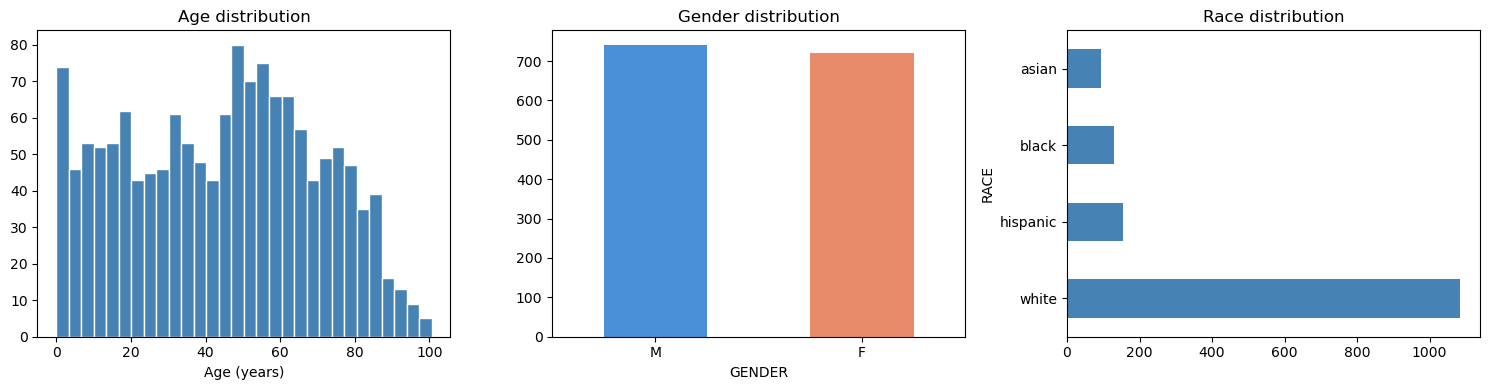

Patients with death recorded: 457 (31.3%)


In [4]:
# 3.1  Demographics overview
# Age at reference date (deceased patients keep their age at death to avoid future leakage)
patients['AGE'] = patients.apply(
    lambda r: (
        (r['DEATHDATE'] if pd.notna(r['DEATHDATE']) else REFERENCE_DATE) - r['BIRTHDATE']
    ).days / 365.25,
    axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(patients['AGE'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age distribution'); axes[0].set_xlabel('Age (years)')

patients['GENDER'].value_counts().plot.bar(ax=axes[1], color=['#4A90D9','#E88B6A'])
axes[1].set_title('Gender distribution'); axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

patients['RACE'].value_counts().plot.barh(ax=axes[2], color='steelblue')
axes[2].set_title('Race distribution')

plt.tight_layout(); plt.show()

print(f"Patients with death recorded: {patients['DEATHDATE'].notna().sum()} "
      f"({patients['DEATHDATE'].notna().mean():.1%})")


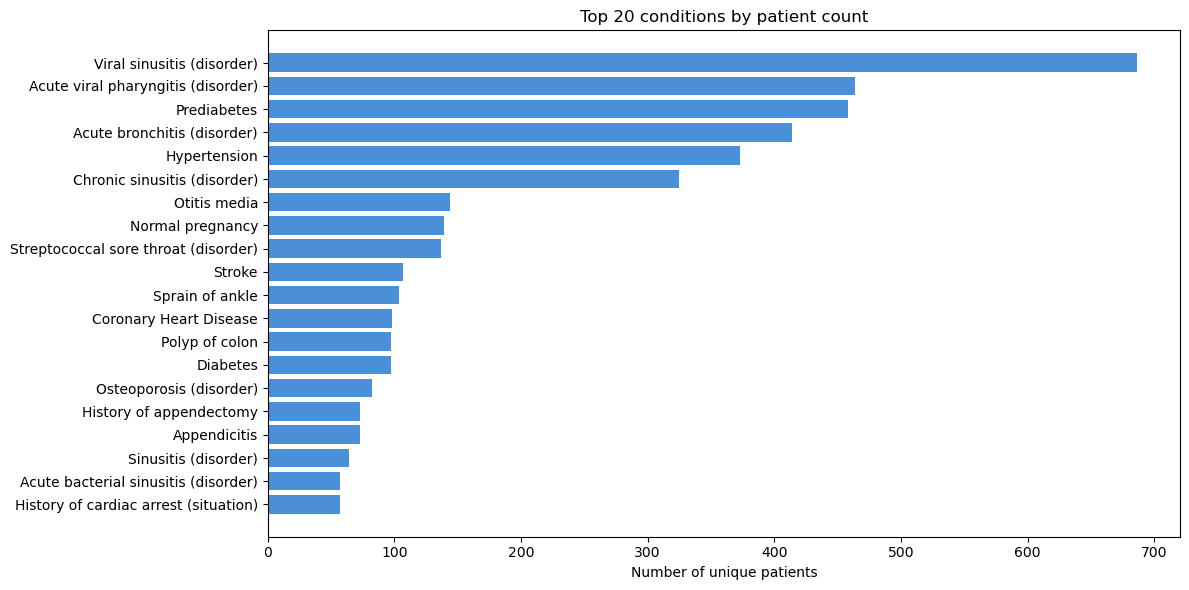

In [5]:
# 3.2  Condition prevalence (top-20 by unique patient count)
cond_prevalence = (
    conditions.groupby('DESCRIPTION')['PATIENT'].nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'PATIENT': 'unique_patients'})
)

plt.figure(figsize=(12, 6))
plt.barh(cond_prevalence['DESCRIPTION'][::-1],
         cond_prevalence['unique_patients'][::-1], color='#4A90D9')
plt.xlabel('Number of unique patients')
plt.title('Top 20 conditions by patient count')
plt.tight_layout(); plt.show()


Key lab value summary:                                           count    mean    std     min     max
DESCRIPTION                                                                   
Body Height                                8473  145.25  38.31   50.96  190.18
Body Mass Index                            7296   27.84   9.58   10.71   53.65
Body Weight                                8473   65.03  39.59    3.40  149.50
Diastolic Blood Pressure                   8473   84.49  12.10   70.00  120.00
Estimated Glomerular Filtration Rate       1898   59.95   0.36   56.00   60.00
Glucose                                    2172   89.03  24.27   64.00  200.00
Hemoglobin A1c/Hemoglobin.total in Blood   4344    6.07   1.09    0.70   12.00
Low Density Lipoprotein Cholesterol        1887   92.82  25.11   51.00  194.00
Systolic Blood Pressure                    8473  129.59  23.69  100.00  200.00
Total Cholesterol                          1887  188.06  24.98  160.00  300.00


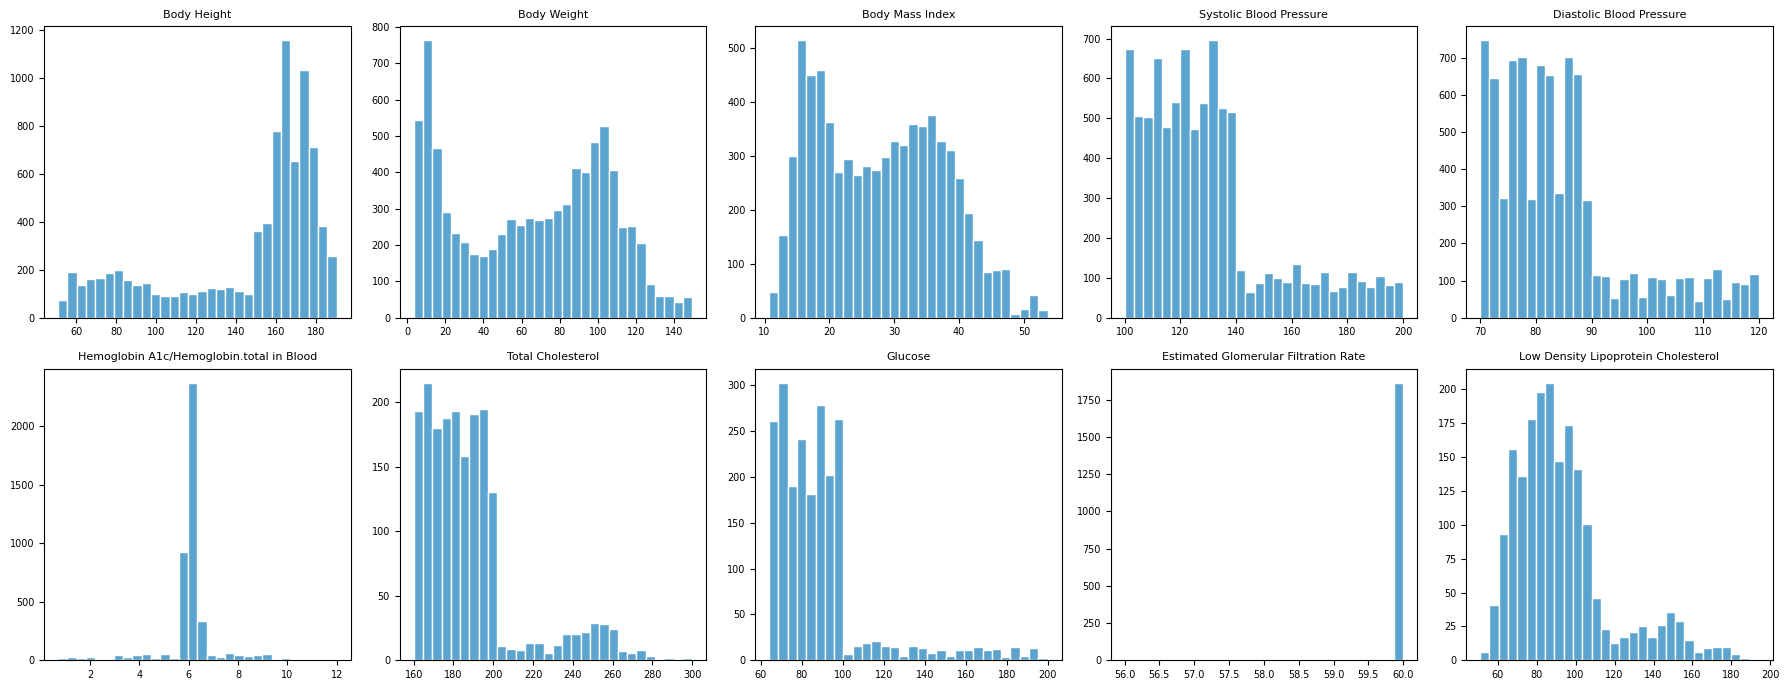

In [6]:
# 3.3  Key lab values – distribution check
KEY_LABS = [
    'Body Height', 'Body Weight', 'Body Mass Index',
    'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Hemoglobin A1c/Hemoglobin.total in Blood',
    'Total Cholesterol', 'Glucose',
    'Estimated Glomerular Filtration Rate',
    'Low Density Lipoprotein Cholesterol',
]
obs_key = observations[observations['DESCRIPTION'].isin(KEY_LABS)].copy()
obs_key['VALUE'] = pd.to_numeric(obs_key['VALUE'], errors='coerce')

g = obs_key.groupby('DESCRIPTION')['VALUE']
summary = g.agg(['count','mean','std','min','max']).round(2)
print("Key lab value summary:", summary.to_string())

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, lab in zip(axes.flat, KEY_LABS):
    vals = obs_key[obs_key['DESCRIPTION'] == lab]['VALUE'].dropna()
    ax.hist(vals, bins=30, color='#5BA4CF', edgecolor='white')
    ax.set_title(lab, fontsize=8)
    ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()


In [7]:
# 3.4  Missingness heatmap 
# Collect null rates across all tables
miss = {}
for name, df in tables.items():
    miss[name] = df.isnull().mean().round(3)

# Display per-table missing rates for tables with any missing data
for name, rates in miss.items():
    hi = rates[rates > 0]
    if len(hi):
        print(f'  {name}: {hi.to_dict()}')


  patients: {'DEATHDATE': 0.687, 'DRIVERS': 0.182, 'PASSPORT': 0.232, 'PREFIX': 0.202, 'SUFFIX': 0.969, 'MAIDEN': 0.724, 'MARITAL': 0.293}
  conditions: {'STOP': 0.438}
  observations: {'ENCOUNTER': 0.037, 'VALUE': 0.006, 'UNITS': 0.006}
  medications: {'STOP': 0.444, 'REASONCODE': 0.406, 'REASONDESCRIPTION': 0.406}
  procedures: {'REASONCODE': 0.749, 'REASONDESCRIPTION': 0.749}
  careplans: {'STOP': 0.46, 'REASONCODE': 0.092, 'REASONDESCRIPTION': 0.092}
  allergies: {'START': 1.0, 'STOP': 1.0}
  encounters: {'REASONCODE': 0.718, 'REASONDESCRIPTION': 0.718}


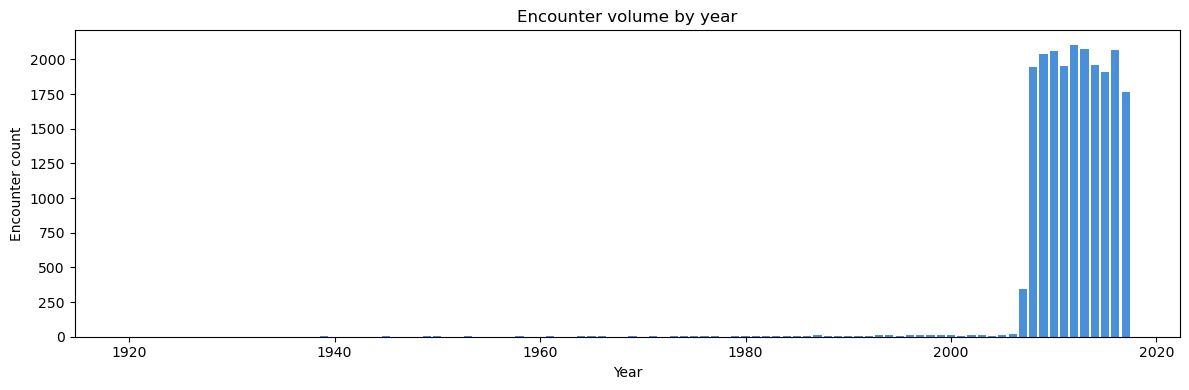

In [8]:
# 3.5  Temporal coverage: records per year
enc_by_year = encounters['DATE'].dt.year.value_counts().sort_index()
plt.figure(figsize=(12, 4))
plt.bar(enc_by_year.index, enc_by_year.values, color='#4A90D9', width=0.8)
plt.title('Encounter volume by year')
plt.xlabel('Year'); plt.ylabel('Encounter count')
plt.tight_layout(); plt.show()


## 4. Target Label Definition (Multilabel) <a id='4-target-labels'></a>

### Why multilabel, not binary?
- 52% of patients have ≥1 chronic condition; conditions co-occur naturally.
- Binary framing (e.g., Diabetes only) throws away correlated risk signal.
- Multilabel sigmoid with `BCEWithLogitsLoss` lets the model learn independent
  per-label probabilities with a single forward pass.

### Label leakage guard
We **only** include conditions that were **resolved before the reference date**
(i.e., `STOP` is not null and `STOP < REFERENCE_DATE`) as historical features.
Ongoing conditions (`STOP` is null) are **targets**, not features.
This simulates the real-world task: given a patient's history, predict what
they will be diagnosed with.

We select the **top-K conditions appearing in ≥50 unique patients** to avoid
extreme label sparsity.


In [9]:
# 4.1  Identify target label pool
MIN_PATIENT_COUNT = 50   # minimum patients for a condition to be a target label

target_cond_counts = (
    conditions.groupby('DESCRIPTION')['PATIENT'].nunique()
    .reset_index()
    .rename(columns={'PATIENT': 'n_patients'})
    .query('n_patients >= @MIN_PATIENT_COUNT')
    .sort_values('n_patients', ascending=False)
)
TARGET_CONDITIONS = target_cond_counts['DESCRIPTION'].tolist()
print(f'Number of target labels: {len(TARGET_CONDITIONS)}')
print(target_cond_counts.to_string(index=False))


Number of target labels: 28
                                          DESCRIPTION  n_patients
                           Viral sinusitis (disorder)         686
                   Acute viral pharyngitis (disorder)         464
                                          Prediabetes         458
                          Acute bronchitis (disorder)         414
                                         Hypertension         373
                         Chronic sinusitis (disorder)         325
                                         Otitis media         144
                                     Normal pregnancy         139
                 Streptococcal sore throat (disorder)         137
                                               Stroke         107
                                      Sprain of ankle         104
                               Coronary Heart Disease          98
                                       Polyp of colon          97
                                             Dia

Label matrix shape: (1376, 28)
Label density (% of labels that are 1): 11.62%


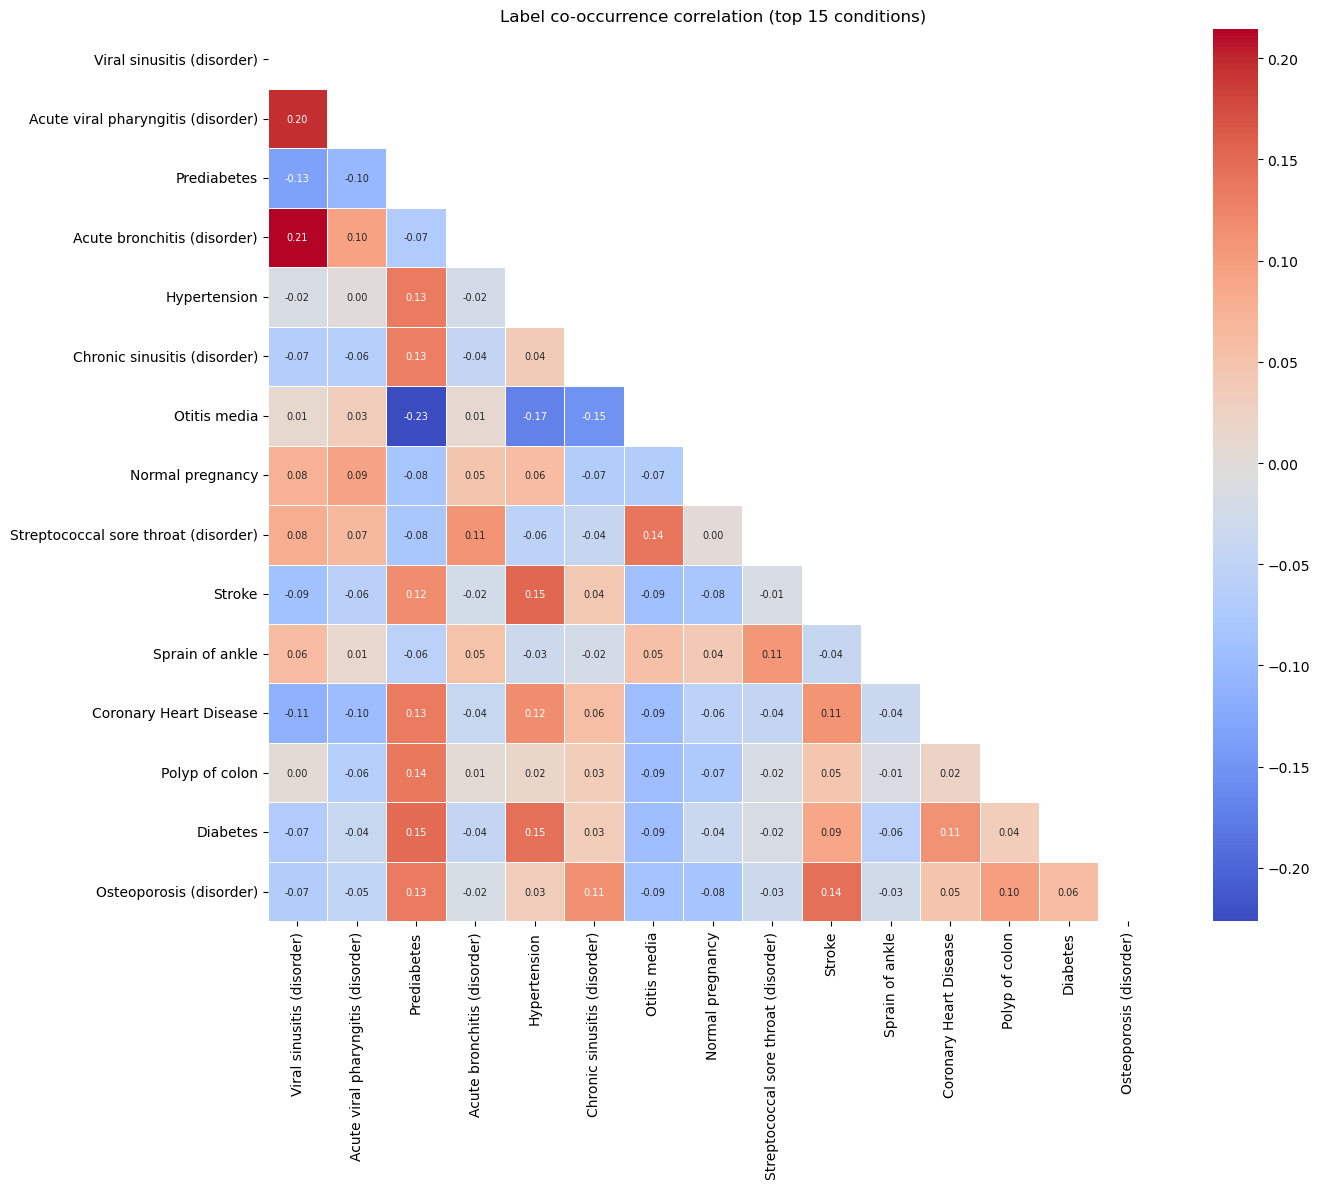

In [10]:
# 4.2  Build multilabel matrix Y 
# For each patient, which of the TARGET_CONDITIONS do they have?
# We use ALL condition occurrences (not restricted to historical only)
# because we're predicting the full condition profile.
# In a temporal split (Section 8) we ensure no future data leaks into features.

cond_target = conditions[conditions['DESCRIPTION'].isin(TARGET_CONDITIONS)].copy()

# Group by patient → set of conditions
patient_conditions = (
    cond_target.groupby('PATIENT')['DESCRIPTION']
    .apply(set)
    .reset_index()
    .rename(columns={'DESCRIPTION': 'condition_set'})
)

# Multi-hot encode
mlb = MultiLabelBinarizer(classes=TARGET_CONDITIONS)
Y_array = mlb.fit_transform(patient_conditions['condition_set'])
Y = pd.DataFrame(Y_array, index=patient_conditions['PATIENT'], columns=mlb.classes_)

print(f'Label matrix shape: {Y.shape}')
print(f'Label density (% of labels that are 1): {Y.values.mean():.2%}')

# Visualise label co-occurrence heatmap (top 15 for readability)
fig, ax = plt.subplots(figsize=(14, 12))
top15 = Y[Y.sum().nlargest(15).index]
corr = top15.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Label co-occurrence correlation (top 15 conditions)', fontsize=12)
plt.tight_layout(); plt.show()


## 5. Feature Engineering Pipeline <a id='5-feature-engineering'></a>

All features are assembled per patient and then joined into a single master matrix.
The primary join key throughout is `PATIENT`.


### 5.1 Demographics

In [11]:
# 5.1  Demographics features
# Drop PII columns (SSN, passport, name, address) to protect privacy
# and prevent overfitting to non-clinical identifiers.

DROP_COLS = ['SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'LAST',
             'SUFFIX', 'MAIDEN', 'BIRTHPLACE', 'ADDRESS']

demo = patients.drop(columns=[c for c in DROP_COLS if c in patients.columns]).copy()

# Age at reference date (already computed in EDA)
demo['AGE'] = demo.apply(
    lambda r: (
        (r['DEATHDATE'] if pd.notna(r['DEATHDATE']) else REFERENCE_DATE) - r['BIRTHDATE']
    ).days / 365.25,
    axis=1
)

# Binary sex flag
demo['IS_FEMALE'] = (demo['GENDER'] == 'F').astype(int)

# Is patient deceased before reference date?
demo['IS_DECEASED'] = (
    demo['DEATHDATE'].notna() & (demo['DEATHDATE'] < REFERENCE_DATE)
).astype(int)

# One-hot encode race and ethnicity
demo = pd.get_dummies(demo, columns=['RACE', 'ETHNICITY', 'GENDER', 'MARITAL'],
                      drop_first=False, dtype=int)

# Keep only feature columns; set PATIENT as index
demo = demo.drop(columns=['BIRTHDATE', 'DEATHDATE'], errors='ignore')
demo = demo.set_index('PATIENT')

print(f'Demographics features: {demo.shape[1]} columns')
print(demo.dtypes.value_counts())


Demographics features: 31 columns
int32      30
float64     1
Name: count, dtype: int64


### 5.2 Temporal Lab/Observation Pivots with Rolling Windows

Instead of collapsing all observations into a single mean, we compute features
in **three temporal windows** relative to the reference date:
- **Recent** (0–6 months): most clinically actionable
- **Mid-term** (6–24 months)
- **Historical** (>24 months)

This transforms the model from a static snapshot into a genuinely longitudinal one,
capturing trajectory information (e.g., rising HbA1c over time).


In [12]:
# 5.2  Observation pivot with temporal windows

# Core lab metrics we pivot (dense enough to avoid sparsity problems)
CORE_LABS = [
    'Body Height', 'Body Weight', 'Body Mass Index',
    'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Hemoglobin A1c/Hemoglobin.total in Blood',
    'Glucose', 'Urea Nitrogen', 'Creatinine',
    'Total Cholesterol', 'Triglycerides',
    'Low Density Lipoprotein Cholesterol',
    'High Density Lipoprotein Cholesterol',
    'Estimated Glomerular Filtration Rate',
    'Calcium', 'Sodium', 'Potassium',
]

obs = observations[observations['DESCRIPTION'].isin(CORE_LABS)].copy()
obs['VALUE'] = pd.to_numeric(obs['VALUE'], errors='coerce')
obs = obs.dropna(subset=['VALUE'])

# Days before reference date
obs['DAYS_BEFORE'] = (REFERENCE_DATE - obs['DATE']).dt.days

def compute_window_features(df, patient_col, value_col, name_col, max_days, label):
    """Compute mean, std, and latest value per patient × lab type within a window."""
    window = df[df['DAYS_BEFORE'] <= max_days].copy()
    agg = (
        window
        .groupby([patient_col, name_col])[value_col]
        .agg(['mean', 'std', 'last'])
        .reset_index()
    )
    # Pivot to wide format: one column per (lab, statistic)
    agg_mean = agg.pivot(index=patient_col, columns=name_col, values='mean')
    agg_std  = agg.pivot(index=patient_col, columns=name_col, values='std')
    agg_last = agg.pivot(index=patient_col, columns=name_col, values='last')

    agg_mean.columns = [f'{c}_{label}_mean' for c in agg_mean.columns]
    agg_std.columns  = [f'{c}_{label}_std'  for c in agg_std.columns]
    agg_last.columns = [f'{c}_{label}_last' for c in agg_last.columns]

    return pd.concat([agg_mean, agg_std, agg_last], axis=1)

# Three windows: recent (<=180d), mid (<=730d), historical (all)
obs_recent   = compute_window_features(obs, 'PATIENT', 'VALUE', 'DESCRIPTION', 180,  'recent')
obs_mid      = compute_window_features(obs, 'PATIENT', 'VALUE', 'DESCRIPTION', 730,  'mid')
obs_hist     = compute_window_features(obs, 'PATIENT', 'VALUE', 'DESCRIPTION', 99999,'hist')

# Merge all three windows on PATIENT index
obs_features = obs_recent.join(obs_mid, how='outer', lsuffix='', rsuffix='_dup')
obs_features = obs_features.join(obs_hist, how='outer', lsuffix='', rsuffix='_dup2')
# Drop any duplicate columns from the join suffixing
obs_features = obs_features.loc[:, ~obs_features.columns.str.endswith(('_dup', '_dup2'))]

print(f'Observation features: {obs_features.shape[1]} columns for {obs_features.shape[0]} patients')


Observation features: 153 columns for 1139 patients


### 5.3 Clinical History — Multi-hot Conditions & Allergies

In [13]:
# 5.3  Clinical history features
# IMPORTANT: We only use RESOLVED conditions (STOP is not null and before reference
# date) as historical features. Ongoing conditions (STOP is null) are potential
# TARGET labels — using them as features would be direct data leakage.

# Resolved conditions as comorbidity history
resolved_conds = conditions[
    conditions['STOP'].notna() &
    (conditions['STOP'] < REFERENCE_DATE)
].copy()

# Count occurrences of each condition per patient (captures recurrence)
cond_counts = (
    resolved_conds.groupby(['PATIENT', 'DESCRIPTION'])
    .size()
    .reset_index(name='count')
)
cond_pivot = cond_counts.pivot(index='PATIENT', columns='DESCRIPTION', values='count').fillna(0)

# Apply variance threshold: drop conditions appearing in fewer than 0.5% of cohort
N_PATIENTS = patients.shape[0]
MIN_PREVALENCE = 0.005                          # 0.5% threshold
min_count_threshold = N_PATIENTS * MIN_PREVALENCE

# Binary flag: has the patient EVER had this resolved condition?
cond_binary = (cond_pivot > 0).astype(int)

# Keep only conditions that exceed the prevalence threshold
cols_to_keep = cond_binary.columns[cond_binary.sum() >= min_count_threshold]
cond_binary  = cond_binary[cols_to_keep]

# Remove target condition columns from features to avoid circular leakage
overlap = set(cond_binary.columns) & set(TARGET_CONDITIONS)
cond_binary = cond_binary.drop(columns=list(overlap), errors='ignore')
cond_binary.columns = [f'hx_{c}' for c in cond_binary.columns]

print(f'Resolved condition history features: {cond_binary.shape[1]} columns')

# Allergy features
# Binary flags for allergy presence; also compute allergy count
allergy_counts = allergies.groupby('PATIENT').size().rename('total_allergies')
allergy_pivot  = (
    allergies.groupby(['PATIENT', 'DESCRIPTION'])
    .size()
    .reset_index(name='count')
    .pivot(index='PATIENT', columns='DESCRIPTION', values='count')
    .fillna(0)
    .clip(upper=1)   # binarise
    .astype(int)
)
allergy_pivot.columns = [f'allergy_{c}' for c in allergy_pivot.columns]

print(f'Allergy features: {allergy_pivot.shape[1]} columns')


Resolved condition history features: 28 columns
Allergy features: 15 columns


### 5.4 Medications — Therapeutic Class Grouping

In [14]:
# 5.4  Medication therapeutic class features 
# Raw medication names are too granular (hundreds of unique strings).
# We map them to broader therapeutic classes, then count active prescriptions
# and class-level exposure per patient.

THERAPEUTIC_CLASS_MAP = {
    # Antibiotics
    'Penicillin': 'antibiotic',
    'Amoxicillin': 'antibiotic',
    'Cefuroxime': 'antibiotic',
    'Nitrofurantoin': 'antibiotic',

    # Analgesics / NSAIDs
    'Acetaminophen': 'analgesic',
    'Ibuprofen': 'analgesic',
    'Naproxen': 'analgesic',
    'Meperidine': 'opioid',
    'oxyCODONE': 'opioid',
    'HYDROcodone': 'opioid',

    # Antidiabetics
    'Metformin': 'antidiabetic',
    'insulin': 'antidiabetic',
    'liraglutide': 'antidiabetic',

    # Cardiovascular / Antihypertensives
    'Amlodipine': 'antihypertensive',
    'Clopidogrel': 'antiplatelet',
    'Simvastatin': 'statin',
    'Nitroglycerin': 'nitrate',
    'Alteplase': 'thrombolytic',

    # Respiratory
    'Fluticasone': 'inhaled_corticosteroid',
    'salmeterol': 'laba',
    'Albuterol': 'saba',

    # Antihistamines / Allergy
    'Fexofenadine': 'antihistamine',
    'Loratadine': 'antihistamine',
    'Chlorpheniramine': 'antihistamine',
    'diphenhydrAMINE': 'antihistamine',
    'EPINEPHrine': 'epinephrine',

    # Oncology
    'Cisplatin': 'chemotherapy',
    'PACLitaxel': 'chemotherapy',
    'Leucovorin': 'chemotherapy_adjunct',
    'oxaliplatin': 'chemotherapy',
    'Etoposide': 'chemotherapy',

    # CNS / Neurological
    'Clonazepam': 'benzodiazepine',
    'Diazepam': 'benzodiazepine',
    'Carbamazepine': 'anticonvulsant',

    # Bone health
    'Alendronic': 'bisphosphonate',

    # Alzheimer's
    'Galantamine': 'acetylcholinesterase_inhibitor',
    'Memantine': 'nmda_antagonist',

    # Contraceptives
    'Jolivette': 'contraceptive',
    'Errin': 'contraceptive',
    'Camila': 'contraceptive',
    'NuvaRing': 'contraceptive',
    'Mirena': 'contraceptive',
    'Nexplanon': 'contraceptive',
    'Implanon': 'contraceptive',
    'Xulane': 'contraceptive',
    'Depo-Provera': 'contraceptive',
    'depo-subQ': 'contraceptive',
    'Trinessa': 'contraceptive',
    'Seasonique': 'contraceptive',
    'Levora': 'contraceptive',
    'Yaz': 'contraceptive',

    # Dermatology
    'Hydrocortisone': 'topical_corticosteroid',

    # Phenazopyridine (UTI symptomatic)
    'Phenazopyridine': 'urinary_analgesic',

    # Dextromethorphan (cough)
    'Dextromethorphan': 'antitussive',
}

def assign_class(description):
    """Return therapeutic class from DESCRIPTION string."""
    if pd.isna(description):
        return 'other'
    for keyword, cls in THERAPEUTIC_CLASS_MAP.items():
        if keyword.lower() in description.lower():
            return cls
    return 'other'

meds = medications.copy()
meds['THERAPEUTIC_CLASS'] = meds['DESCRIPTION'].apply(assign_class)

# Feature 1: Number of TOTAL unique prescription events per patient
total_rx = meds.groupby('PATIENT').size().rename('total_prescriptions')
# Log-transform to reduce skew from outliers (one patient has 81 prescriptions)
total_rx_log = np.log1p(total_rx).rename('log_total_prescriptions')

# Feature 2: Count of ACTIVE medications at reference date
# Active = START before reference AND (STOP is null OR STOP >= reference)
active_meds = meds[
    (meds['START'] < REFERENCE_DATE) &
    (meds['STOP'].isna() | (meds['STOP'] >= REFERENCE_DATE))
]
active_count = active_meds.groupby('PATIENT').size().rename('active_medication_count')

# Feature 3: Therapeutic class exposure (binary flags)
class_pivot = (
    meds.groupby(['PATIENT', 'THERAPEUTIC_CLASS'])
    .size()
    .reset_index(name='count')
    .pivot(index='PATIENT', columns='THERAPEUTIC_CLASS', values='count')
    .fillna(0)
    .clip(upper=1)
    .astype(int)
)
class_pivot.columns = [f'rx_{c}' for c in class_pivot.columns]

# Merge medication features
med_features = pd.concat([total_rx, total_rx_log, active_count, class_pivot], axis=1)
print(f'Medication features: {med_features.shape[1]} columns for {med_features.shape[0]} patients')


Medication features: 28 columns for 1318 patients


### 5.5 Utilisation — Procedures, Encounters, Immunisations

In [15]:
# 5.5  Utilisation features 

# Procedure counts (total + unique procedure types)
proc_total  = procedures.groupby('PATIENT').size().rename('total_procedures')
proc_unique = procedures.groupby('PATIENT')['CODE'].nunique().rename('unique_procedure_types')

# Encounter counts by type
enc_counts = (
    encounters.groupby(['PATIENT', 'DESCRIPTION'])
    .size()
    .reset_index(name='count')
    .pivot(index='PATIENT', columns='DESCRIPTION', values='count')
    .fillna(0)
    .astype(int)
)
# Keep only high-frequency encounter types to avoid sparsity
enc_freq_cols = enc_counts.columns[enc_counts.sum() >= 100]
enc_counts    = enc_counts[enc_freq_cols]
enc_counts.columns = [f'enc_{c.replace(" ","_").lower()[:30]}' for c in enc_counts.columns]
enc_total     = encounters.groupby('PATIENT').size().rename('total_encounters')

# Emergency visits flag (high-risk signal)
emergency_visits = (
    encounters[encounters['DESCRIPTION'].str.contains('Emergency|emergency', na=False)]
    .groupby('PATIENT').size()
    .rename('emergency_visit_count')
)

# Immunisation features
imm_total   = immunizations.groupby('PATIENT').size().rename('total_immunizations')
imm_unique  = immunizations.groupby('PATIENT')['CODE'].nunique().rename('unique_vaccines')
# Influenza vaccine count (most common; strong health engagement proxy)
flu_count   = (
    immunizations[immunizations['DESCRIPTION'].str.contains('Influenza', na=False)]
    .groupby('PATIENT').size()
    .rename('flu_vaccine_count')
)

# Active care plans count
active_cp = careplans[
    (careplans['START'] < REFERENCE_DATE) &
    (careplans['STOP'].isna() | (careplans['STOP'] >= REFERENCE_DATE))
]
active_cp_count = active_cp.groupby('PATIENT').size().rename('active_careplan_count')

# Merge utilisation features
util_features = pd.concat([
    proc_total, proc_unique,
    enc_counts, enc_total, emergency_visits,
    imm_total, imm_unique, flu_count,
    active_cp_count
], axis=1)
print(f'Utilisation features: {util_features.shape[1]} columns for {util_features.shape[0]} patients')


Utilisation features: 23 columns for 1461 patients


### 5.6 Master Feature Matrix Assembly

In [16]:
# 5.6  Join all feature blocks on PATIENT index 
all_patients = pd.Index(patients['PATIENT'].unique(), name='PATIENT')

def reindex_fill(df, idx):
    """Reindex to full patient cohort; fill missing with 0."""
    return df.reindex(idx).fillna(0)

X = (
    reindex_fill(demo,          all_patients)
    .join(reindex_fill(obs_features,  all_patients), how='left')
    .join(reindex_fill(cond_binary,   all_patients), how='left')
    .join(reindex_fill(allergy_pivot, all_patients), how='left')
    .join(reindex_fill(med_features,  all_patients), how='left')
    .join(reindex_fill(util_features, all_patients), how='left')
)

# Drop any remaining object/bool columns that slipped through
X = X.select_dtypes(include=[np.number]).fillna(0)

print(f'Master feature matrix: {X.shape[0]} patients × {X.shape[1]} features')
print(f'Null values remaining: {X.isnull().sum().sum()}')


Master feature matrix: 1462 patients × 278 features
Null values remaining: 0


## 6. Feature Importance & Selection (LightGBM) <a id='6-feature-importance'></a>

We run a fast LightGBM model on each target label independently to extract
structural feature importance scores, then aggregate across labels.
Features appearing in fewer than `MIN_PREVALENCE` of the cohort are also
dropped via a variance threshold filter.


In [17]:
# 6.1  Variance threshold filter 
vt = VarianceThreshold(threshold=0.005)   # ~0.5% minimum variance
X_vt = pd.DataFrame(
    vt.fit_transform(X),
    index=X.index,
    columns=X.columns[vt.get_support()]
)
print(f'Features after variance threshold: {X_vt.shape[1]} (dropped {X.shape[1] - X_vt.shape[1]})')


Features after variance threshold: 262 (dropped 16)


In [18]:
# 6.2  LightGBM importance across all target labels 
# Align X and Y to the same patient index
common_idx = X_vt.index.intersection(Y.index)
X_aligned  = X_vt.loc[common_idx]
Y_aligned  = Y.reindex(common_idx).fillna(0)

importance_accumulator = pd.Series(0.0, index=X_aligned.columns)
LGBM_PARAMS = dict(
    objective='binary',
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbose=-1,
    n_jobs=-1,
)

print('Training LightGBM per label for feature importance...')
for label in TARGET_CONDITIONS:
    if label not in Y_aligned.columns:
        continue
    y_label = Y_aligned[label]
    # Skip if fewer than 10 positive examples
    if y_label.sum() < 10:
        continue
    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(X_aligned, y_label)
    importance_accumulator += pd.Series(
        model.feature_importances_,
        index=X_aligned.columns
    )

# Normalise
importance_accumulator = importance_accumulator / importance_accumulator.sum()
importance_sorted = importance_accumulator.sort_values(ascending=False)

print(f'\nTop 30 features by aggregated LightGBM importance:')
print(importance_sorted.head(30).round(4).to_string())


Training LightGBM per label for feature importance...

Top 30 features by aggregated LightGBM importance:
AGE                                               0.0953
active_careplan_count                             0.0455
total_prescriptions                               0.0350
active_medication_count                           0.0272
enc_encounter_for_symptom                         0.0229
Body Height_hist_mean                             0.0211
Systolic Blood Pressure_hist_std                  0.0209
total_encounters                                  0.0196
Diastolic Blood Pressure_hist_std                 0.0171
Diastolic Blood Pressure_hist_mean                0.0159
Systolic Blood Pressure_hist_mean                 0.0158
unique_procedure_types                            0.0133
Body Weight_hist_std                              0.0127
Body Mass Index_hist_std                          0.0119
rx_analgesic                                      0.0116
Body Mass Index_hist_mean              

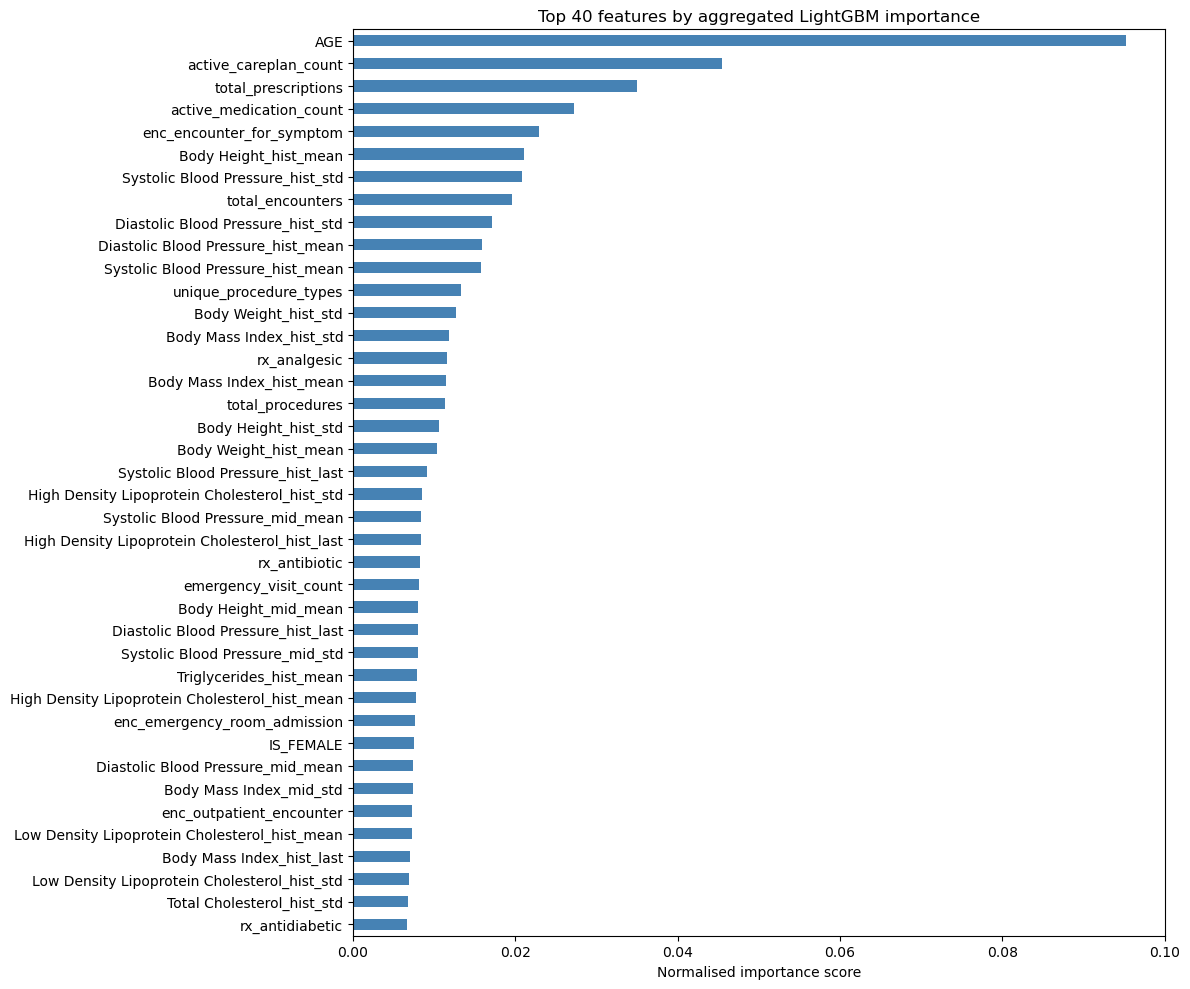


Final tabular feature set: 80 features × 1376 patients


In [19]:
# 6.3  Visualise and select top features 
TOP_N_FEATURES = 80   # keep top-N features for the MLP; tune as needed

top_features = importance_sorted.head(TOP_N_FEATURES).index.tolist()
X_selected   = X_aligned[top_features]

plt.figure(figsize=(12, 10))
importance_sorted.head(40).sort_values().plot.barh(color='steelblue')
plt.title('Top 40 features by aggregated LightGBM importance')
plt.xlabel('Normalised importance score')
plt.tight_layout(); plt.show()

print(f'\nFinal tabular feature set: {X_selected.shape[1]} features × {X_selected.shape[0]} patients')


## 7. Clinical Text Synthesis (LLM Prompt Template) <a id='7-text-synthesis'></a>

BioClinical (ModernBert) processes **unstructured clinical text**, not numerical matrices.
We use an LLM (e.g. GPT-4o or Claude) to synthesise a structured clinical narrative
for each patient, then pass that text through the frozen BioClinical encoder.

### Prompt design principles
- Use **structured sequence strings** not prose paragraphs — BioClinical is trained on
  clinical notes and SNOMED-style sequences.
- Include only **historical** (pre-reference) information to avoid leakage.
- Keep summaries under restricted tokens (BioClinical's max context length).


In [20]:
# 7.1  Clinical narrative synthesis function 
# This function generates the prompt payload for each patient.
# In production, batch all patients and call your LLM API once per patient.

def build_patient_prompt(patient_id: str) -> str:
    """
    Build a structured clinical narrative prompt for a single patient.
    Returns the raw string to send to your LLM API.
    
    The LLM should be instructed (via system prompt) to respond with
    a concise clinical note in the style of a physician's summary,
    under 400 words, using clinical terminology.
    """
    # Demographics 
    p = patients[patients['PATIENT'] == patient_id].iloc[0]
    age   = round((REFERENCE_DATE - p['BIRTHDATE']).days / 365.25)
    sex   = 'female' if p['GENDER'] == 'F' else 'male'
    race  = p.get('RACE', 'unknown')

    # Historical resolved conditions 
    hist_conds = conditions[
        (conditions['PATIENT'] == patient_id) &
        conditions['STOP'].notna() &
        (conditions['STOP'] < REFERENCE_DATE)
    ]['DESCRIPTION'].unique().tolist()

    # Current medications (active at reference date) 
    active_meds_list = meds[
        (meds['PATIENT'] == patient_id) &
        (meds['START'] < REFERENCE_DATE) &
        (meds['STOP'].isna() | (meds['STOP'] >= REFERENCE_DATE))
    ]['DESCRIPTION'].unique().tolist()

    # Allergies 
    allergy_list = allergies[
        allergies['PATIENT'] == patient_id
    ]['DESCRIPTION'].unique().tolist()

    # Latest key lab values 
    pat_obs = observations[
        (observations['PATIENT'] == patient_id) &
        (observations['DATE'] < REFERENCE_DATE)
    ].sort_values('DATE', ascending=False)

    lab_lines = []
    for lab in ['Body Mass Index', 'Systolic Blood Pressure',
                'Hemoglobin A1c/Hemoglobin.total in Blood',
                'Total Cholesterol', 'Estimated Glomerular Filtration Rate']:
        row = pat_obs[pat_obs['DESCRIPTION'] == lab]
        if len(row):
            val  = row.iloc[0]['VALUE']
            unit = row.iloc[0]['UNITS']
            lab_lines.append(f'{lab}: {val} {unit}')

    # Procedure history 
    proc_list = procedures[
        (procedures['PATIENT'] == patient_id) &
        (procedures['DATE'] < REFERENCE_DATE)
    ]['DESCRIPTION'].unique().tolist()[:5]   # cap at 5 for brevity

    # Assemble prompt 
    # Pre-processing logic for cleaner input
    pmh_input = '; '.join(hist_conds) if hist_conds else "Non-contributory"
    meds_input = '; '.join(active_meds_list) if active_meds_list else "No active medications"
    labs_input = chr(10).join('  ' + l for l in lab_lines) if lab_lines else "Vitals and labs unremarkable"
    procs_input = '; '.join(proc_list) if proc_list else "None"

    # Logic check: Is this patient 'healthy' based on our data?
    is_healthy = not hist_conds and not active_meds_list and not lab_lines

    prompt = f"""
    Generate a professional SOAP note for the following patient data:

    PATIENT DATA:
    - Demographics: {age}yo {sex}, {race}
    - PMH: {pmh_input}
    - Meds: {meds_input}
    - Allergies: {'; '.join(allergy_list) if allergy_list else 'NKDA'}
    - Labs/Vitals: 
    {labs_input}
    - Procedures: {procs_input}

    INSTRUCTIONS:
    - S: Summarize demographics and history. If PMH is empty, note 'well-appearing patient'.
    - O: List objective findings.
    - A: Assessment. {'IMPORTANT: If the patient is healthy, explicitly state '
    '"No acute clinical concerns".' if is_healthy else 'Synthesize findings. '
                       'If labs (like BP or BMI) are abnormal, list the clinical impression here.'}
    - P: Note 'Continue current management' or specific follow-ups.
    - Keep the total length under 250 words for optimal BERT encoding.
    """
    return prompt


#  7.2  Demo: print a sample prompt for one patient 
sample_pid = patients['PATIENT'].iloc[0]
print(build_patient_prompt(sample_pid))



    Generate a professional SOAP note for the following patient data:

    PATIENT DATA:
    - Demographics: 89yo female, black
    - PMH: Non-contributory
    - Meds: No active medications
    - Allergies: NKDA
    - Labs/Vitals: 
    Vitals and labs unremarkable
    - Procedures: None

    INSTRUCTIONS:
    - S: Summarize demographics and history. If PMH is empty, note 'well-appearing patient'.
    - O: List objective findings.
    - A: Assessment. IMPORTANT: If the patient is healthy, explicitly state "No acute clinical concerns".
    - P: Note 'Continue current management' or specific follow-ups.
    - Keep the total length under 250 words for optimal BERT encoding.
    


In [21]:
import os

from groq import Groq, RateLimitError

client = Groq(
    api_key=os.environ.get("GROQ_API_KEY"),
)


In [22]:
# 7.3  Batch text generation (API call template)
import pandas as pd
from pathlib import Path

NOTES_CACHE_PATH = Path('clinical_notes_cache.csv')

SYSTEM_PROMPT = (
    "You are a Clinical Informatics Specialist. Your task is to synthesize structured data "
    "into a high-density SOAP note for downstream NLP extraction. "
    "1. TERMINOLOGY: Use standard clinical shorthand (e.g., PMH, NKDA, WNL, HTN, DM2). "
    "2. HEALTHY PATIENTS: If a patient has no documented chronic conditions and labs are "
    "within normal limits, explicitly state 'No acute clinical concerns' in the Assessment. "
    "3. SPARSE DATA: If a section is empty, do not say 'None'; use 'Unremarkable', 'Non-contributory', "
    "or 'Routine health maintenance' to provide clinical context. "
    "4. SYNTHESIS: Critically evaluate laboratory/vital signs. If labs are abnormal but not listed "
    "in the history, include the clinical impression in the 'Assessment' section. "
    "5. FORMAT: Output plain text only. No markdown, no bolding, no headers like '###'. "
    "Use a single line break between SOAP sections."
)

def generate_clinical_note(patient_id: str) -> str:
    """
    Generate a clinical text note for a patient using an LLM.
    Returns the generated string. Replace the stub below with a real API call.
    """
    prompt = build_patient_prompt(patient_id)

    response = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT,
            },
            {"role": "user", "content": prompt},
        ],
        model="llama-3.1-8b-instant",
        temperature=0.2,
    )

    return response.choices[0].message.content.strip()


# Generate notes for all patients in the aligned cohort (run once, then cache)
# print('Generating clinical notes (stub mode)...')
# clinical_notes = {pid: generate_clinical_note(pid) for pid in common_idx}  # demo: first 5
# for pid, note in list(clinical_notes.items())[:2]:
#     print(f'\n--- Patient {pid[:8]}... ---')
#     print(note[:300])

# 1) Load whatever we finished on previous runs (survives kernel restarts too)
if NOTES_CACHE_PATH.exists():
    clinical_notes = pd.read_csv(NOTES_CACHE_PATH, index_col=0)['note'].to_dict()
    print(f'Resuming: {len(clinical_notes)} notes already cached.')
else:
    clinical_notes = {}            # <-- lives in namespace BEFORE the loop

def save_progress():
    (pd.DataFrame.from_dict(clinical_notes, orient='index', columns=['note'])
       .to_csv(NOTES_CACHE_PATH))

# 2) Only work on patients we haven't done yet
remaining = [pid for pid in common_idx if pid not in clinical_notes]
print(f'{len(remaining)} patients remaining of {len(common_idx)}.')

failed_pid = None
try:
    for i, pid in enumerate(remaining, 1):
        clinical_notes[pid] = generate_clinical_note(pid)   # mutate the dict in place
        if i % 25 == 0:                                     # periodic flush to disk
            save_progress()
            print(f'  ...{i}/{len(remaining)} done, cached.')
except Exception as e:
    # quota / rate-limit / network / anything: keep what we have
    failed_pid = pid
    print(f'\n[STOPPED] crashed on {pid} after {len(clinical_notes)} successful notes.')
    print(f'  reason: {type(e).__name__}: {e}')
finally:
    save_progress()   # always persist, crash or clean finish
    print(f'Saved {len(clinical_notes)} notes to {NOTES_CACHE_PATH}')


Resuming: 1376 notes already cached.
0 patients remaining of 1376.
Saved 1376 notes to clinical_notes_cache.csv


In [23]:


# notes_df = pd.DataFrame.from_dict(clinical_notes, orient='index', columns=['note'])
# notes_df

# Load from cache if it exists
NOTES_CACHE_PATH = Path('clinical_notes_cache.csv')
if NOTES_CACHE_PATH.exists():
    notes_df = pd.read_csv(NOTES_CACHE_PATH, index_col=0)
    print(f'Loaded {len(notes_df)} cached clinical notes.')
else:
    # Fallback: generate placeholder notes for all patients in cohort
    notes_dict = {pid: generate_clinical_note(pid) for pid in common_idx}
    notes_df   = pd.DataFrame.from_dict(notes_dict, orient='index', columns=['note'])
    print(f'Generated {len(notes_df)} clinical notes (stub mode — replace with real LLM calls).')

Loaded 1376 cached clinical notes.


In [24]:
notes_df.iloc[0]['note']

'S: 74yo Black male presents for follow-up. PMH includes acute bronchitis, acute bacterial sinusitis, acute viral pharyngitis, and viral sinusitis. Current meds: Naproxen sodium 220 mg PRN. NKDA.\n\nO: SBP 106.0 mmHg. BMI 28.64 kg/m2. HbA1c 6.4%, Total Cholesterol 195.0 mg/dL. Hx of colonoscopy, sputum exam, and percutaneous mechanical thrombectomy of portal vein under fluoroscopy. Meds documented. Physical exam is unremarkable.\n\nA: Prediabetes (HbA1c 6.4%, elevated risk for DM2) and overweight (BMI 28.64). Hx of portal vein thrombosis s/p mechanical thrombectomy, clinically stable. Resolved acute respiratory infections. Borderline hypercholesterolemia.\n\nP: Counsel on low-glycemic diet and exercise for prediabetes and weight management. Repeat HbA1c and lipid panel in 6 months. Continue Naproxen PRN. Routine health maintenance and follow-up as scheduled.'

## 8. Dataset Splits — Patient-Level K-Fold <a id='8-dataset-splits'></a>

**Critical:** we must split at the **patient level**, not the row level.
Splitting encounter-level rows would leak patient history across folds
(the same patient appearing in both train and validation).

We use 5-fold stratification on the presence of the most common condition
(Viral sinusitis) as a proxy to maintain class balance across folds.


In [25]:
# Align final X, Y, and notes
# Ensure all three data sources share the same patient index
final_idx = common_idx.intersection(notes_df.index)

X_final = X_selected.reindex(final_idx).fillna(0)
Y_final = Y_aligned.reindex(final_idx).fillna(0).astype(float)
notes_final = notes_df.reindex(final_idx)['note'].fillna('No clinical note available.')

print(f'Final aligned cohort: {len(final_idx)} patients')
print(f'Tabular features: {X_final.shape[1]}')
print(f'Target labels: {Y_final.shape[1]}')

# Scale tabular features
scaler  = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_final),
    index=X_final.index,
    columns=X_final.columns
)

Final aligned cohort: 1376 patients
Tabular features: 80
Target labels: 28


In [26]:
Y_final

,Viral sinusitis (disorder),Acute viral pharyngitis (disorder),Prediabetes,Acute bronchitis (disorder),Hypertension,Chronic sinusitis (disorder),Otitis media,Normal pregnancy,Streptococcal sore throat (disorder),Stroke,...,Acute bacterial sinusitis (disorder),History of cardiac arrest (situation),Cardiac Arrest,Osteoarthritis of knee,History of single seizure (situation),Seizure disorder,Chronic obstructive bronchitis (disorder),Concussion with no loss of consciousness,Suspected lung cancer (situation),Neuropathy due to type 2 diabetes mellitus (disorder)
aaa4c718-2f48-4c13-9ad0-d287cf280824,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
a1851c06-804e-4f31-9d8f-388cd52d4ad0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48074b70-4db4-4ab0-b9e8-361bd2ba6216,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
a4a67345-d7e5-4246-8e06-ed043a9764e2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53244745-9198-41c8-83b7-1647d98cc618,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131717c-e009-446d-b353-0b865cbb4194,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
462abede-dc9a-4928-a120-0449155d6ada,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6e687318-9491-4453-8877-da816d835499,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c0cb1ff4-8fbe-4f93-990d-abf62284cb4d,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
X_scaled

,AGE,active_careplan_count,total_prescriptions,active_medication_count,enc_encounter_for_symptom,Body Height_hist_mean,Systolic Blood Pressure_hist_std,total_encounters,Diastolic Blood Pressure_hist_std,Diastolic Blood Pressure_hist_mean,...,ETHNICITY_chinese,RACE_white,ETHNICITY_african,Potassium_hist_std,allergy_Shellfish allergy,RACE_black,rx_bisphosphonate,ETHNICITY_german,Potassium_hist_mean,Calcium_hist_last
aaa4c718-2f48-4c13-9ad0-d287cf280824,1.152011,1.746390,0.376508,-0.405487,1.483169,0.973758,0.694395,0.372361,0.264228,0.210157,...,-0.200151,-1.689480,4.996225,1.236298,-0.175247,3.177542,-0.213524,-0.233251,1.649827,1.819770
a1851c06-804e-4f31-9d8f-388cd52d4ad0,0.708724,2.241912,2.420642,2.721538,-0.035690,0.628707,1.943631,0.095965,0.151766,0.924818,...,-0.200151,0.591898,-0.200151,1.953339,-0.175247,-0.314709,4.683304,-0.233251,1.900507,1.959290
48074b70-4db4-4ab0-b9e8-361bd2ba6216,1.497530,2.737433,0.603634,2.274820,-0.035690,0.753077,1.479277,0.165064,0.980054,1.150078,...,-0.200151,-1.689480,-0.200151,1.831336,-0.175247,-0.314709,-0.213524,-0.233251,1.775341,1.620456
a4a67345-d7e5-4246-8e06-ed043a9764e2,1.463867,1.746390,-0.077744,0.041231,-1.048263,0.864295,0.305478,-0.111332,0.274709,1.040534,...,-0.200151,0.591898,-0.200151,1.044097,5.706223,-0.314709,-0.213524,4.287223,1.762477,1.799839
53244745-9198-41c8-83b7-1647d98cc618,1.375988,1.498629,0.830760,1.381384,1.989456,0.900831,0.082157,0.165064,0.310648,0.378639,...,-0.200151,0.591898,-0.200151,2.084747,-0.175247,-0.314709,-0.213524,-0.233251,1.644380,1.837210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131717c-e009-446d-b353-0b865cbb4194,1.634183,-0.978980,-0.077744,-0.852205,-0.035690,0.641276,1.492431,0.095965,0.654470,1.073860,...,-0.200151,-1.689480,-0.200151,-0.516796,-0.175247,3.177542,-0.213524,-0.233251,-0.569779,-0.569513
462abede-dc9a-4928-a120-0449155d6ada,1.645404,-0.235697,-0.077744,0.041231,1.989456,0.758631,1.293077,0.026866,0.879242,1.060591,...,-0.200151,0.591898,-0.200151,1.840918,-0.175247,-0.314709,4.683304,-0.233251,1.683784,1.695199
6e687318-9491-4453-8877-da816d835499,1.661180,1.003107,0.149382,0.487948,1.989456,0.722241,0.583976,0.026866,-0.115216,0.279895,...,-0.200151,0.591898,-0.200151,1.848118,-0.175247,-0.314709,-0.213524,-0.233251,1.640324,1.779907
c0cb1ff4-8fbe-4f93-990d-abf62284cb4d,1.664735,2.737433,-0.077744,-0.405487,-0.035690,0.402765,0.956124,0.095965,1.223083,1.090523,...,-0.200151,0.591898,-0.200151,1.545875,-0.175247,-0.314709,-0.213524,-0.233251,1.740573,1.620456


In [27]:
# 5-Fold patient-level cross-validation splits
# Stratify on the single most prevalent label
stratify_col = Y_final['Viral sinusitis (disorder)'].astype(int)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_scaled, stratify_col)):
    folds.append((train_idx, val_idx))
    train_pos = stratify_col.iloc[train_idx].sum()
    val_pos   = stratify_col.iloc[val_idx].sum()
    print(f'Fold {fold_idx+1}: {len(train_idx)} train | {len(val_idx)} val | '
          f'pos in train: {train_pos} | pos in val: {val_pos}')


Fold 1: 1100 train | 276 val | pos in train: 548 | pos in val: 138
Fold 2: 1101 train | 275 val | pos in train: 549 | pos in val: 137
Fold 3: 1101 train | 275 val | pos in train: 549 | pos in val: 137
Fold 4: 1101 train | 275 val | pos in train: 549 | pos in val: 137
Fold 5: 1101 train | 275 val | pos in train: 549 | pos in val: 137


## 9. Tabular Branch — MLP with BatchNorm & Dropout <a id='9-mlp-branch'></a>

The tabular branch processes the engineered feature matrix through a deep MLP
with batch normalisation (for training stability with diverse feature scales)
and dropout (to prevent overfitting on the 1,500-patient cohort).

Output: a 256-dimensional embedding vector that represents the patient's
clinical profile in a dense latent space.


In [28]:
#  PyTorch Dataset
class EHRDataset(Dataset):
    """
    Unified dataset returning tabular features, tokenised clinical text,
    and multilabel targets for each patient.
    """
    def __init__(self, X_df, notes_series, Y_df, tokenizer, max_len=512):
        self.X        = torch.tensor(X_df.values, dtype=torch.float32)
        self.Y        = torch.tensor(Y_df.values, dtype=torch.float32)
        self.notes    = notes_series.tolist()
        self.tokenizer = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Tabular features
        x_tab = self.X[idx]

        # Tokenise clinical note
        enc = self.tokenizer(
            self.notes[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        # Labels 
        y = self.Y[idx]

        return x_tab, input_ids, attention_mask, y


In [29]:
# MLP architecture
class TabularMLP(nn.Module):
    """
    Multi-Layer Perceptron for tabular EHR features.

    Architecture:
        Input(n_features)
        → Linear(512) + BatchNorm + ReLU + Dropout(0.3)
        → Linear(256) + BatchNorm + ReLU + Dropout(0.3)
        → Linear(256) + BatchNorm + ReLU + Dropout(0.2)
        → Linear(256)  [output embedding]

    BatchNorm before activation stabilises training with features of
    very different scales (lab values, binary flags, counts).
    Dropout reduces overfitting on the ~1,500-patient cohort.
    """
    def __init__(self, n_features: int, hidden_dims=(512, 256, 256), embed_dim=256,
                 dropout_rates=(0.3, 0.3, 0.2)):
        super().__init__()
        dims = [n_features] + list(hidden_dims)
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                nn.Linear(dims[i], dims[i+1]),
                nn.BatchNorm1d(dims[i+1]),
                nn.ReLU(),
                nn.Dropout(dropout_rates[min(i, len(dropout_rates)-1)]),
            ]
        layers.append(nn.Linear(hidden_dims[-1], embed_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)   # → (batch, embed_dim)


# Quick sanity check
n_features = X_final.shape[1]
mlp = TabularMLP(n_features=n_features)
dummy_input = torch.randn(4, n_features)
print(f'MLP output shape: {mlp(dummy_input).shape}')   # expect (4, 256)
print(mlp)


MLP output shape: torch.Size([4, 256])
TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=80, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=256, out_features=256, bias=True)
  )
)


## 10. Text Branch — Frozen BioClinical Encoder + Projection Head <a id='10-text-branch'></a>

We use `thomas-sounack/BioClinical-ModernBERT-large`
(a strong biomedical BERT in the HuggingFace ecosystem).

### Why freeze the encoder initially?
- With only ~1,200 training patients, fine-tuning all 110M parameters
  of the encoder would cause catastrophic forgetting.
- Freezing extracts stable biomedical representations trained on millions
  of clinical abstracts, then our small classification head learns on top.
- We unfreeze the last 2–3 transformer layers in a later fine-tuning pass
  (Section 15) once the fusion head has converged.

### Projection head
Raw `BioClinical-ModernBERT-large` output is 1024 dimensions. Our MLP outputs 256 dimensions.
Concatenating them directly (1024 + 256 = 1,280) gives the text branch 4×
the dimensionality — it would dominate the fused representation.
A `Linear(1024 → 256) + ReLU` projection head before fusion balances both branches.


In [ ]:
BIOCLINICAL_MODEL = 'thomas-sounack/BioClinical-ModernBERT-large'

print(f'Loading tokeniser and encoder from: {BIOCLINICAL_MODEL}')
tokenizer    = AutoTokenizer.from_pretrained(BIOCLINICAL_MODEL)
bioclinical_base = AutoModel.from_pretrained(BIOCLINICAL_MODEL)   # base encoder, not ...ForMaskedLM

# Freeze ALL encoder parameters
for param in bioclinical_base.parameters():
    param.requires_grad = False

# Put the frozen encoder in eval mode so its dropout/norm behave as a fixed extractor
bioclinical_base.eval()

print(f'Encoder hidden size: {bioclinical_base.config.hidden_size}')   # 1024 for -large
trainable = sum(p.numel() for p in bioclinical_base.parameters() if p.requires_grad)
total     = sum(p.numel() for p in bioclinical_base.parameters())
print(f'bioclinical trainable params: {trainable:,} / {total:,} (frozen)')

Loading tokeniser and encoder from: thomas-sounack/BioClinical-ModernBERT-large


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder hidden size: 1024
OpenMed trainable params: 0 / 394,781,696 (frozen)


In [ ]:
class BioClinicalEncoder(nn.Module):
    def __init__(self, base_model, proj_dim=256, dropout=0.1, hidden_size=None):
        super().__init__()
        self.encoder = base_model            # frozen
        hidden_size = hidden_size or base_model.config.hidden_size
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state                       # (B, T, H)

        # Masked mean pooling over the token dimension
        mask = attention_mask.unsqueeze(-1).type_as(hidden)      # (B, T, 1)
        summed = (hidden * mask).sum(dim=1)                      # (B, H)
        counts = mask.sum(dim=1).clamp(min=1e-9)                # (B, 1), avoid /0
        pooled = summed / counts                                # (B, H)

        return self.projection(pooled)                          # (B, 256)


text_encoder = BioClinicalEncoder(bioclinical_base)
trainable = sum(p.numel() for p in text_encoder.parameters() if p.requires_grad)
total     = sum(p.numel() for p in text_encoder.parameters())
print(f'Text encoder trainable params: {trainable:,} / {total:,}')

# Shape check
dummy_ids  = torch.randint(0, 1000, (2, 64))
dummy_mask = torch.ones(2, 64, dtype=torch.long)
print(f'Text encoder output shape: {text_encoder(dummy_ids, dummy_mask).shape}')  # (2, 256)

Text encoder trainable params: 262,400 / 395,044,096
Text encoder output shape: torch.Size([2, 256])


## 11. Fusion & Classification Head <a id='11-fusion'></a>

The fusion layer concatenates the 256-d tabular embedding and the 256-d projected
text embedding into a 512-d joint representation.
A final dropout and linear layer map this to the `K` target condition logits.

### Fusion options (in order of recommendation for this cohort size)
1. **Projected concatenation** ← implemented here (stable, interpretable, fast)
2. **Cross-modal attention** (text queries tabular; more expressive but higher overfitting risk)
3. **Gating** (`g = sigmoid(W·tab)` gates the text contribution)

Concatenation is recommended for cohort N ≈ 1,500.


In [ ]:
# Full hybrid model 
class HybridEHRModel(nn.Module):
    """
    Two-branch hybrid model for multilabel EHR condition prediction.

    Branches
    --------
    Tabular branch  : TabularMLP  → 256-d embedding
    Text branch     : BioClinicalEncoder (frozen) → 256-d projected embedding

    Fusion
    ------
    concat([tab_emb, text_emb]) → 512-d
    → Dropout(0.2)
    → Linear(512, n_labels)
    → Sigmoid at inference (BCEWithLogitsLoss is numerically stable at train time)

    Parameters
    ----------
    n_features  : number of tabular input features
    n_labels    : number of target condition labels
    embed_dim   : shared embedding dimension (default 256)
    dropout_fusion : dropout rate on fused representation (default 0.2)
    """
    def __init__(self, n_features: int, n_labels: int,
                 embed_dim: int = 256, dropout_fusion: float = 0.2,
                 bioclinical_base_model=None):
        super().__init__()

        self.tab_branch  = TabularMLP(n_features=n_features, embed_dim=embed_dim)
        self.text_branch = BioClinicalEncoder(bioclinical_base_model or bioclinical_base,
                                              proj_dim=embed_dim)

        fusion_dim = embed_dim * 2  # 512 after concat
        self.fusion_dropout = nn.Dropout(dropout_fusion)
        self.classifier     = nn.Linear(fusion_dim, n_labels)

    def forward(self, x_tab, input_ids, attention_mask):
        tab_emb  = self.tab_branch(x_tab)                           # (B, 256)
        text_emb = self.text_branch(input_ids, attention_mask)      # (B, 256)

        fused   = torch.cat([tab_emb, text_emb], dim=-1)           # (B, 512)
        fused   = self.fusion_dropout(fused)
        logits  = self.classifier(fused)                            # (B, n_labels)
        return logits


# Instantiate and inspect 
N_LABELS   = Y_final.shape[1]
N_FEATURES = X_final.shape[1]

model = HybridEHRModel(n_features=N_FEATURES, n_labels=N_LABELS)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:>12,}')
print(f'Trainable parameters: {trainable_params:>12,}')

# Shape check
dummy_tab  = torch.randn(4, N_FEATURES).to(DEVICE)
dummy_ids  = torch.randint(0, 1000, (4, 64)).to(DEVICE)
dummy_mask = torch.ones(4, 64, dtype=torch.long).to(DEVICE)
print(f'Output logits shape: {model(dummy_tab, dummy_ids, dummy_mask).shape}')  # (4, K)


Total parameters:      395,364,892
Trainable parameters:      583,196
Output logits shape: torch.Size([4, 28])


## 12. Training Loop with Class Weighting & Label Smoothing <a id='12-training'></a>

### Class imbalance handling
Labels range from 686 positive patients (viral sinusitis) to 51 (neuropathy).
We compute per-label positive weights and pass them to `BCEWithLogitsLoss`:
`pos_weight[i] = n_negative[i] / n_positive[i]`
This up-weights loss on rare positive examples.

### Label smoothing
Hard 0/1 labels can cause overconfident predictions. We apply smoothing ε=0.05:
`y_smooth = y * (1 - ε) + ε/2`
This regularises the classifier head without changing the architecture.

### Training strategy (two stages)
- **Stage 1** (20–30 epochs): Train tabular MLP + projection head + classifier.
  BioClinical encoder is fully frozen. Learning rate 1e-3.
- **Stage 2** (Section 15): Unfreeze last 2 transformer layers of BioClinical.
  Use a very small LR (1e-5) to gently adapt the encoder without forgetting.


In [34]:
# Loss function with class weights 
def compute_pos_weights(Y_train_df: pd.DataFrame) -> torch.Tensor:
    """
    Compute per-label positive weights for BCEWithLogitsLoss.
    Weight = n_negative / n_positive (clamped to avoid division by zero).
    """
    n_pos = Y_train_df.sum(axis=0).clip(lower=1)
    n_neg = len(Y_train_df) - n_pos
    weights = (n_neg / n_pos).clip(upper=20)   # cap at 20× to avoid instability
    return torch.tensor(weights.values, dtype=torch.float32)


def label_smoothing(y: torch.Tensor, eps: float = 0.05) -> torch.Tensor:
    """Apply label smoothing: y_smooth = y*(1-eps) + eps/2"""
    return y * (1 - eps) + eps / 2


In [35]:
# Training and validation step functions 
def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0
    for x_tab, input_ids, attention_mask, y in loader:
        x_tab, input_ids = x_tab.to(device), input_ids.to(device)
        attention_mask   = attention_mask.to(device)
        y_smooth         = label_smoothing(y.to(device))

        optimiser.zero_grad()
        logits = model(x_tab, input_ids, attention_mask)
        loss   = criterion(logits, y_smooth)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimiser.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    for x_tab, input_ids, attention_mask, y in loader:
        x_tab, input_ids = x_tab.to(device), input_ids.to(device)
        attention_mask   = attention_mask.to(device)

        logits = model(x_tab, input_ids, attention_mask)
        total_loss += criterion(logits, y.to(device)).item()

        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    logits_cat = torch.cat(all_logits, dim=0)
    labels_cat = torch.cat(all_labels, dim=0)
    probs      = torch.sigmoid(logits_cat).numpy()
    labels_np  = labels_cat.numpy()

    # Compute macro AUC-ROC (only for labels with both classes present in val set)
    valid_labels = [i for i in range(labels_np.shape[1])
                    if labels_np[:, i].sum() > 0 and (1 - labels_np[:, i]).sum() > 0]
    if valid_labels:
        auc = roc_auc_score(labels_np[:, valid_labels],
                            probs[:, valid_labels], average='macro')
    else:
        auc = float('nan')

    return total_loss / len(loader), auc, probs, labels_np


In [36]:
import os
import torch

# ── Checkpoint config ──────────────────────────────────────────────────
CKPT_DIR  = 'checkpoints/fold0'
os.makedirs(CKPT_DIR, exist_ok=True)
LAST_CKPT = os.path.join(CKPT_DIR, 'last.pt')   # overwritten every epoch → resume point
BEST_CKPT = os.path.join(CKPT_DIR, 'best.pt')   # best val AUC so far

def trimmed_state_dict(model):
    """State dict WITHOUT the frozen encoder (reloaded from pretrained on resume).
    Keeps trainable params AND any buffers in the tab branch (e.g. BatchNorm stats)."""
    return {k: v.detach().cpu() for k, v in model.state_dict().items()
            if not k.startswith('text_branch.encoder.')}

def save_checkpoint(path, *, epoch, model, optimiser, scheduler,
                    best_auc, best_state, history):
    tmp = path + '.tmp'
    torch.save({
        'epoch':       epoch,                 # last COMPLETED epoch
        'model_state': trimmed_state_dict(model),
        'optim_state': optimiser.state_dict(),
        'sched_state': scheduler.state_dict(),
        'best_auc':    best_auc,
        'best_state':  best_state,
        'history':     history,
        'rng':         torch.get_rng_state(),
    }, tmp)
    os.replace(tmp, path)   # atomic: a crash mid-save can't corrupt the live file


# ── Config ──────────────────────────────────────────────────────────────
BATCH_SIZE = 16
N_EPOCHS   = 30
LR         = 1e-3

train_idx_0, val_idx_0 = folds[0]
X_tr, X_vl = X_scaled.iloc[train_idx_0], X_scaled.iloc[val_idx_0]
Y_tr, Y_vl = Y_final.iloc[train_idx_0],  Y_final.iloc[val_idx_0]
notes_tr, notes_vl = notes_final.iloc[train_idx_0], notes_final.iloc[val_idx_0]

pos_weights = compute_pos_weights(Y_tr).to(DEVICE)
criterion   = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

train_dataset = EHRDataset(X_tr, notes_tr, Y_tr, tokenizer, max_len=512)
val_dataset   = EHRDataset(X_vl, notes_vl, Y_vl, tokenizer, max_len=512)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# ── Model / optimiser / scheduler ───────────────────────────────────────
model     = HybridEHRModel(n_features=N_FEATURES, n_labels=N_LABELS).to(DEVICE)
optimiser = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=N_EPOCHS)

# ── Resume if a checkpoint exists ───────────────────────────────────────
start_epoch = 1
best_auc    = 0.0
best_state  = None
train_losses, val_losses, val_aucs = [], [], []

if os.path.exists(LAST_CKPT):
    print(f'Resuming from {LAST_CKPT}')
    ckpt = torch.load(LAST_CKPT, map_location='cpu')
    # encoder keys are intentionally absent → strict=False (it loads fresh from pretrained)
    model.load_state_dict(ckpt['model_state'], strict=False)
    optimiser.load_state_dict(ckpt['optim_state'])
    scheduler.load_state_dict(ckpt['sched_state'])
    # move optimiser state tensors onto DEVICE (load brings them in as CPU tensors)
    for state in optimiser.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(DEVICE)
    best_auc    = ckpt['best_auc']
    best_state  = ckpt['best_state']
    train_losses, val_losses, val_aucs = ckpt['history']
    torch.set_rng_state(ckpt['rng'])
    start_epoch = ckpt['epoch'] + 1
    print(f'  → continuing from epoch {start_epoch} (best AUC so far: {best_auc:.4f})')

# ── Training loop ───────────────────────────────────────────────────────
print(f'Training on {len(train_dataset)} patients | Validating on {len(val_dataset)} patients')
print(f'Device: {DEVICE} | Epochs: {N_EPOCHS} | Batch size: {BATCH_SIZE}')
print('-' * 65)

for epoch in range(start_epoch, N_EPOCHS + 1):
    tr_loss               = train_one_epoch(model, train_loader, optimiser, criterion, DEVICE)
    vl_loss, vl_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    val_aucs.append(vl_auc)

    is_best = vl_auc > best_auc
    if is_best:
        best_auc   = vl_auc
        best_state = trimmed_state_dict(model)

    history = (train_losses, val_losses, val_aucs)
    save_checkpoint(LAST_CKPT, epoch=epoch, model=model, optimiser=optimiser,
                    scheduler=scheduler, best_auc=best_auc, best_state=best_state,
                    history=history)
    if is_best:
        save_checkpoint(BEST_CKPT, epoch=epoch, model=model, optimiser=optimiser,
                        scheduler=scheduler, best_auc=best_auc, best_state=best_state,
                        history=history)

    if epoch % 5 == 0 or epoch == 1 or is_best:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  '
              f'Train loss: {tr_loss:.4f}  '
              f'Val loss: {vl_loss:.4f}  '
              f'Val AUC-ROC: {vl_auc:.4f}  '
              f'{"← best" if is_best else ""}')

print(f'\nBest validation AUC-ROC: {best_auc:.4f}')

Training on 1100 patients | Validating on 276 patients
Device: cuda | Epochs: 30 | Batch size: 16
-----------------------------------------------------------------
Epoch   1/30  Train loss: 1.2670  Val loss: 0.9105  Val AUC-ROC: 0.7982  ← best
Epoch   2/30  Train loss: 1.1596  Val loss: 0.8619  Val AUC-ROC: 0.8143  ← best
Epoch   3/30  Train loss: 1.1282  Val loss: 0.8401  Val AUC-ROC: 0.8259  ← best
Epoch   4/30  Train loss: 1.1059  Val loss: 0.8024  Val AUC-ROC: 0.8348  ← best
Epoch   5/30  Train loss: 1.0892  Val loss: 0.8032  Val AUC-ROC: 0.8397  ← best
Epoch   9/30  Train loss: 1.0383  Val loss: 0.7652  Val AUC-ROC: 0.8474  ← best
Epoch  10/30  Train loss: 1.0244  Val loss: 0.7624  Val AUC-ROC: 0.8401  
Epoch  15/30  Train loss: 0.9892  Val loss: 0.7567  Val AUC-ROC: 0.8465  
Epoch  16/30  Train loss: 0.9790  Val loss: 0.7411  Val AUC-ROC: 0.8524  ← best
Epoch  20/30  Train loss: 0.9635  Val loss: 0.7414  Val AUC-ROC: 0.8492  
Epoch  25/30  Train loss: 0.9418  Val loss: 0.7342  Va

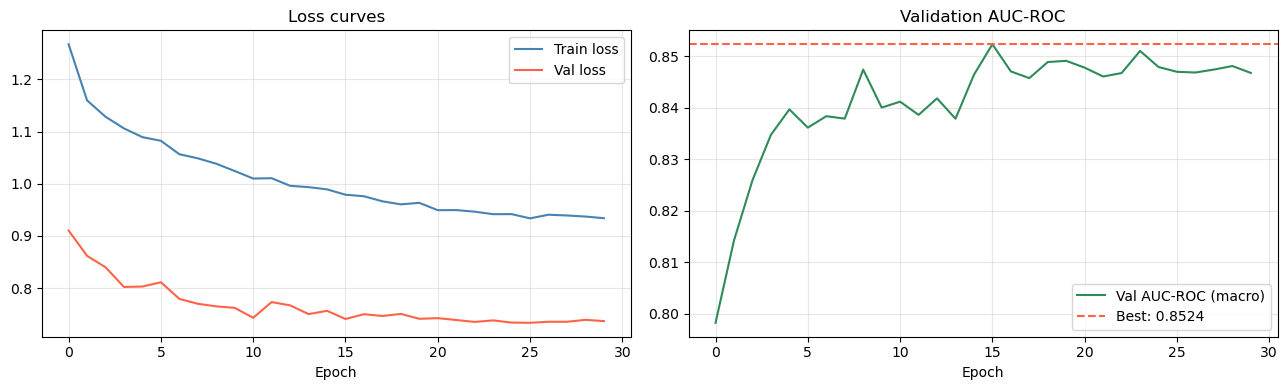

In [37]:
# Plot training curves 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, label='Train loss', color='steelblue')
ax1.plot(val_losses,   label='Val loss',   color='tomato')
ax1.set_title('Loss curves'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(val_aucs, color='seagreen', label='Val AUC-ROC (macro)')
ax2.axhline(best_auc, color='tomato', linestyle='--', label=f'Best: {best_auc:.4f}')
ax2.set_title('Validation AUC-ROC'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 13. Evaluation — AUC-ROC, F1-macro, Per-label Metrics <a id='13-evaluation'></a>


In [39]:
# ── 13.1  Load best model state and evaluate ──────────────────────────────
# best_state omits the frozen ModernBERT (text_branch.encoder.*), which is already
# loaded in `model` from from_pretrained — so load non-strict.
missing, unexpected = model.load_state_dict(
    {k: v.to(DEVICE) for k, v in best_state.items()}, strict=False
)
# sanity: the only missing keys should be the frozen encoder, and nothing unexpected
assert all(k.startswith('text_branch.encoder.') for k in missing), missing
assert not unexpected, unexpected

_, best_val_auc, val_probs, val_labels = evaluate(model, val_loader, criterion, DEVICE)
print(f'Best model — Macro AUC-ROC: {best_val_auc:.4f}')

per_label_auc = {}
for i, label in enumerate(TARGET_CONDITIONS):
    y_true = val_labels[:, i]
    y_pred = val_probs[:, i]
    if y_true.sum() > 0 and (1 - y_true).sum() > 0:
        per_label_auc[label] = roc_auc_score(y_true, y_pred)

per_label_df = pd.Series(per_label_auc).sort_values(ascending=False)
print('\nPer-label AUC-ROC:')
print(per_label_df.round(4).to_string())

Best model — Macro AUC-ROC: 0.8524

Per-label AUC-ROC:
Coronary Heart Disease                                   1.0000
Diabetes                                                 1.0000
Normal pregnancy                                         0.9902
Neuropathy due to type 2 diabetes mellitus (disorder)    0.9897
Hypertension                                             0.9849
Prediabetes                                              0.9845
Chronic obstructive bronchitis (disorder)                0.9820
Otitis media                                             0.9794
Osteoporosis (disorder)                                  0.9775
Suspected lung cancer (situation)                        0.9596
History of cardiac arrest (situation)                    0.9368
Cardiac Arrest                                           0.9350
Polyp of colon                                           0.9244
Stroke                                                   0.8861
Acute bronchitis (disorder)                      

F1 macro (threshold=0.5): 0.4387
F1 micro (threshold=0.5): 0.4636


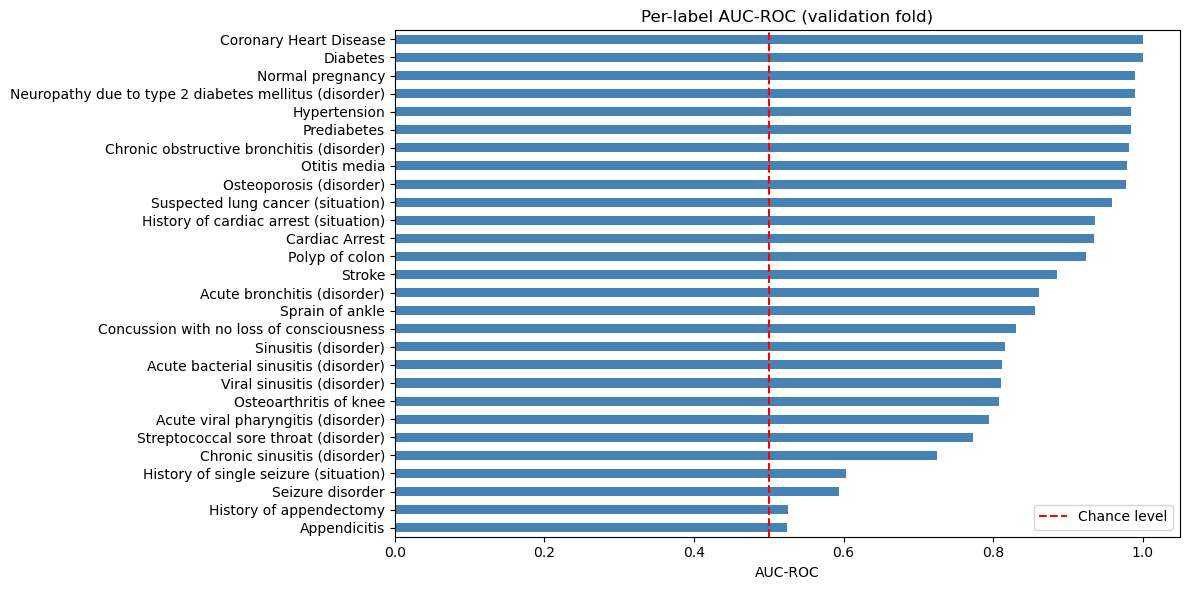

In [40]:
# ── 13.2  F1-macro at default threshold 0.5 ─────────────────────────────
val_preds_binary = (val_probs >= 0.5).astype(int)
f1_macro = f1_score(val_labels, val_preds_binary, average='macro', zero_division=0)
f1_micro = f1_score(val_labels, val_preds_binary, average='micro', zero_division=0)

print(f'F1 macro (threshold=0.5): {f1_macro:.4f}')
print(f'F1 micro (threshold=0.5): {f1_micro:.4f}')

# ── 13.3  Visualise per-label AUC-ROC ────────────────────────────────────
plt.figure(figsize=(12, 6))
per_label_df.sort_values().plot.barh(color='steelblue')
plt.axvline(0.5, color='red', linestyle='--', label='Chance level')
plt.title('Per-label AUC-ROC (validation fold)')
plt.xlabel('AUC-ROC')
plt.legend(); plt.tight_layout(); plt.show()


## 14. Threshold Tuning per Label <a id='14-threshold-tuning'></a>

The optimal sigmoid threshold varies per label depending on class prevalence
and clinical cost trade-offs. We search for the threshold that maximises F1
for each label independently on the validation fold.

**In production** this threshold should be tuned on a held-out calibration set,
not the test set, to avoid optimistic bias.


In [41]:
# ── 14.1  Per-label threshold optimisation ────────────────────────────────
from sklearn.metrics import f1_score as sk_f1

THRESHOLD_GRID = np.arange(0.1, 0.91, 0.05)
optimal_thresholds = {}

for i, label in enumerate(TARGET_CONDITIONS):
    y_true = val_labels[:, i]
    if y_true.sum() == 0:
        optimal_thresholds[label] = 0.5
        continue

    best_f1, best_thresh = 0.0, 0.5
    for thresh in THRESHOLD_GRID:
        y_pred = (val_probs[:, i] >= thresh).astype(int)
        f1 = sk_f1(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    optimal_thresholds[label] = best_thresh

thresh_df = pd.Series(optimal_thresholds, name='optimal_threshold').sort_values()
print('Optimal per-label thresholds:')
print(thresh_df.round(2).to_string())

# ── 14.2  F1 with optimal thresholds ─────────────────────────────────────
val_preds_tuned = np.zeros_like(val_probs, dtype=int)
for i, label in enumerate(TARGET_CONDITIONS):
    val_preds_tuned[:, i] = (val_probs[:, i] >= optimal_thresholds[label]).astype(int)

f1_macro_tuned = sk_f1(val_labels, val_preds_tuned, average='macro', zero_division=0)
f1_micro_tuned = sk_f1(val_labels, val_preds_tuned, average='micro', zero_division=0)

print(f'\nF1 macro (tuned thresholds): {f1_macro_tuned:.4f}  '
      f'[vs {f1_macro:.4f} at 0.5]')
print(f'F1 micro (tuned thresholds): {f1_micro_tuned:.4f}  '
      f'[vs {f1_micro:.4f} at 0.5]')


Optimal per-label thresholds:
Viral sinusitis (disorder)                               0.35
Appendicitis                                             0.40
History of appendectomy                                  0.40
Acute viral pharyngitis (disorder)                       0.45
Chronic sinusitis (disorder)                             0.45
Streptococcal sore throat (disorder)                     0.50
Coronary Heart Disease                                   0.55
Acute bronchitis (disorder)                              0.60
Hypertension                                             0.60
Diabetes                                                 0.65
Normal pregnancy                                         0.65
Sprain of ankle                                          0.70
Prediabetes                                              0.70
Concussion with no loss of consciousness                 0.75
Suspected lung cancer (situation)                        0.75
Chronic obstructive bronchitis (disorder

## 15. Optional: Unfreeze Top BioClinical Layers (Stage 2 Fine-tuning) <a id='15-fine-tuning'></a>

After the Stage 1 classification head has converged, we selectively unfreeze
the **last 2 transformer layers** of the BioClinical encoder and continue training
with a very small learning rate (1e-5).

This allows the biomedical representations to adapt slightly to the EHR
domain without catastrophic forgetting of pre-trained knowledge.

**When to apply:**
- Only if Stage 1 validation AUC-ROC has plateaued.
- Monitor validation loss carefully — stop immediately if it increases.
- Keep the learning rate ≤ 1e-5 for encoder layers.


In [ ]:
N_UNFREEZE_LAYERS = 2

# ModernBERT: transformer blocks live in `.layers` (BERT used `.encoder.layer`)
modernbert  = model.text_branch.encoder.encoder      # the ModernBertModel
bert_layers = modernbert.layers

n_layers = len(bert_layers)                           # 28 for -large
for i, layer in enumerate(bert_layers):
    requires_grad = (i >= n_layers - N_UNFREEZE_LAYERS)
    for param in layer.parameters():
        param.requires_grad = requires_grad

# No pooler in ModernBERT. The analogue in your mean-pooling path is final_norm,
# which is applied to last_hidden_state — optional but reasonable to unfreeze.
for param in modernbert.final_norm.parameters():
    param.requires_grad = True

# (optional but recommended) start Stage 2 from the BEST Stage-1 weights, not the
# last epoch. best_state is the trimmed head+tab dict, so strict=False.
if best_state is not None:
    model.load_state_dict(best_state, strict=False)

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after unfreezing: {trainable_ft:,}')

In [ ]:
# ── 15.3  Save final model ────────────────────────────────────────────────
import pickle

# Save model weights
torch.save(best_state, 'hybrid_ehr_model_best.pt')

# Save scaler and feature columns for inference
import joblib
joblib.dump(scaler, 'feature_scaler.pkl')

model_metadata = {
    'feature_columns': X_final.columns.tolist(),
    'target_conditions': TARGET_CONDITIONS,
    'optimal_thresholds': optimal_thresholds,
    'n_features': N_FEATURES,
    'n_labels': N_LABELS,
    'BioClinical_model_name': BioClinical_MODEL,
}
with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print('Saved:')
print('  hybrid_ehr_model_best.pt  — model weights')
print('  feature_scaler.pkl        — StandardScaler')
print('  model_metadata.pkl        — feature list, thresholds, label names')


---
## Summary

| Component | Choice | Rationale |
|---|---|---|
| **Target** | Multilabel (top-K conditions, sigmoid + BCE) | Conditions co-occur; binary framing loses signal |
| **Features** | Demographics + temporal lab pivots + multi-hot history + therapeutic classes + utilisation | Covers all 10 tables; temporal windows capture trajectory |
| **Leakage guard** | Historical features = resolved conditions only (STOP not null) | Ongoing conditions are potential targets |
| **Selection** | LightGBM importance + variance threshold (≥0.5%) | Reduces noise before neural training |
| **Text** | LLM → clinical note → frozen BioClinical → 768-d → projection → 256-d | Stable biomedical representations; balanced with tabular branch |
| **Fusion** | Projected concatenation (256 ‖ 256 → 512) | Dimensionally balanced; stable at N≈1,500 |
| **Class imbalance** | BCEWithLogitsLoss with pos_weight | Handles label skew without resampling |
| **Regularisation** | Label smoothing ε=0.05, dropout, gradient clipping | Prevents overconfidence on small cohort |
| **Evaluation** | Per-label AUC-ROC + F1 with tuned thresholds | Appropriate for imbalanced multilabel setting |
| **Fine-tuning** | Unfreeze last 2 BioClinical layers with LR=1e-5 | Gentle domain adaptation without catastrophic forgetting |
